In [1]:
!pip install tensorflow matplotlib

  Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached tensorflow_intel-2.18.0-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.3.25-py2.py3-none-any.whl.metadata (850 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.1-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached grpcio-1.68.1-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached keras-3.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.1.0 requires fsspec[http]<=2024.9.0,>=2023.1.0, but you have fsspec 2024.10.0 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
transformers 4.46.3 requires tokenizers<0.21,>=0.20, but you have tokenizers 0.21.0 which is incompatible.


In [2]:
!pip install numpy==1.26.4 fsspec==2024.9.0 tokenizers==0.20.0

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached fsspec-2024.9.0-py3-none-any.whl.metadata (11 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Using cached fsspec-2024.9.0-py3-none-any.whl (179 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------ --------------------- 1.0/2.3 MB 12.5 MB/s eta 0:00:01
   ------------------------------------ --- 2.1/2.3 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.0
    Uninstalling tokenizers-0.21.0:
      Successfu

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os

In [7]:
# 1. Veri Yollarını Tanımla
train_dir = "D:/SYSTEM/DataGast/prepared-dataset/train"
val_dir = "D:/SYSTEM/DataGast/prepared-dataset/validation"
test_dir = "D:/SYSTEM/DataGast/prepared-dataset/test"

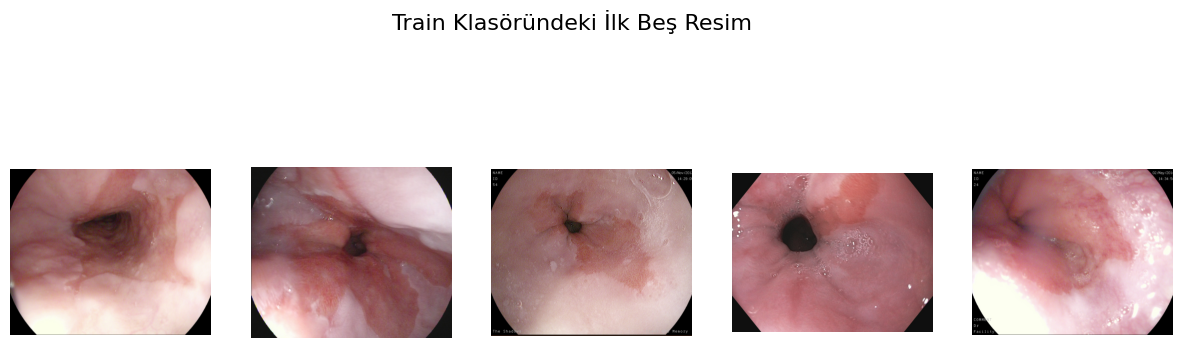

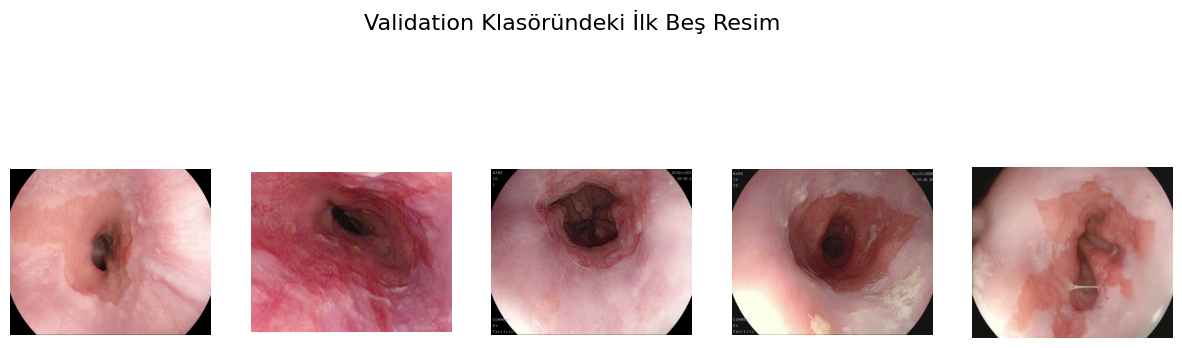

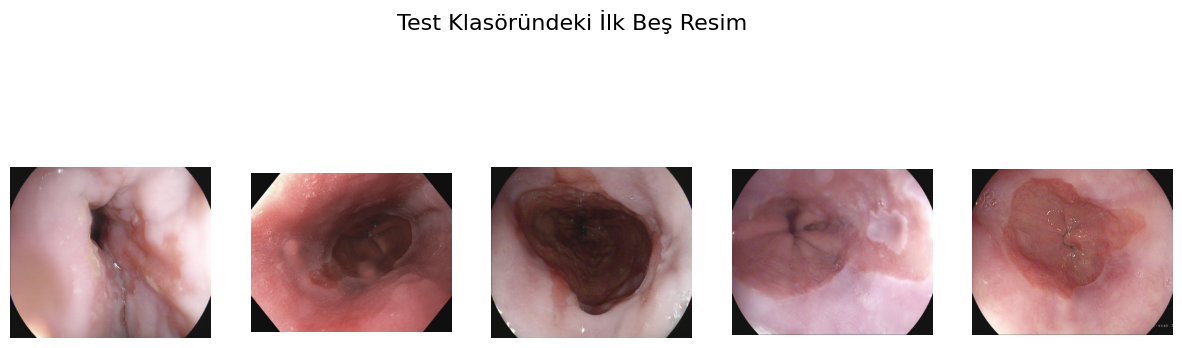

In [20]:
import matplotlib.image as mpimg
# Her klasörden ilk beş resmi göster
def show_first_five_images(dir_path, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    
    image_count = 0  # Gösterilen resim sayısını takip etmek için
    
    for root, _, files in os.walk(dir_path):  # Alt klasörler dahil tüm dosyaları dolaş
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Resim dosyası olup olmadığını kontrol et
                image_path = os.path.join(root, file)
                img = mpimg.imread(image_path)
                
                if image_count < 5:  # İlk beş resmi göster
                    axes[image_count].imshow(img)
                    axes[image_count].axis('off')
                    image_count += 1
                else:
                    break  # Beş resim gösterildikten sonra döngüden çık
        
        if image_count >= 5:  # Beş resim gösterildiyse döngüden çık
            break
    
    plt.show()

show_first_five_images(train_dir, "Train Klasöründeki İlk Beş Resim")
show_first_five_images(val_dir, "Validation Klasöründeki İlk Beş Resim")
show_first_five_images(test_dir, "Test Klasöründeki İlk Beş Resim")

In [8]:
# 2. Sabit Parametreler
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 50

In [9]:
# 3. Veri Ön İşleme ve Artırma (Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Piksel değerlerini normalize et
    rotation_range=30,       # Rastgele döndürme
    width_shift_range=0.2,   # Yatay kaydırma
    height_shift_range=0.2,  # Dikey kaydırma
    shear_range=0.2,         # Kesme dönüşümü
    zoom_range=0.2,          # Yakınlaştırma
    horizontal_flip=True,    # Yatay çevirme
    fill_mode='nearest'      # Boşluk doldurma modu
)

val_datagen = ImageDataGenerator(rescale=1./255)  # Normalizasyon
test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
# train_generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# val_generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# test_generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 7463 images belonging to 23 classes.
Found 1599 images belonging to 23 classes.
Found 1600 images belonging to 23 classes.


In [11]:
from tensorflow.keras import Input

# 5. CNN Modelini Tanımla
model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),  # Input nesnesiyle giriş boyutunu tanımla
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')  # Çoklu sınıf çıktısı
])

In [12]:
# 6. Modeli Derle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# 7. Early Stopping Callback Tanımla
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [15]:
# 8 Modeli Eğit (workers ve multiprocessing burada ayarlanır)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


C:\Users\LordFelison\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3175 - loss: 2.2969

C:\Users\LordFelison\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


234/234 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.3179 - loss: 2.2951 - val_accuracy: 0.6016 - val_loss: 1.2232
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.5604 - loss: 1.3241 - val_accuracy: 0.6898 - val_loss: 0.8747
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.6235 - loss: 1.1128 - val_accuracy: 0.7117 - val_loss: 0.7979
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.6510 - loss: 1.0040 - val_accuracy: 0.7017 - val_loss: 0.8316
Epoch 5/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.6562 - loss: 0.9815 - val_accuracy: 0.7086 - val_loss: 0.8019
Epoch 6/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.6673 - loss: 0.9603 - val_accuracy: 0.7555 - val_loss: 0.6711
Epoch 7/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.6718 - loss: 0.9074 - val_accuracy: 0.7517 - val_loss: 0.6501
Epoch 8/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.6809 - loss: 0.8833 - val_accuracy: 0.744

In [16]:
# 9. Test Seti ile Modeli Değerlendir
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 866ms/step - accuracy: 0.8146 - loss: 0.4627
Test Accuracy: 78.44%


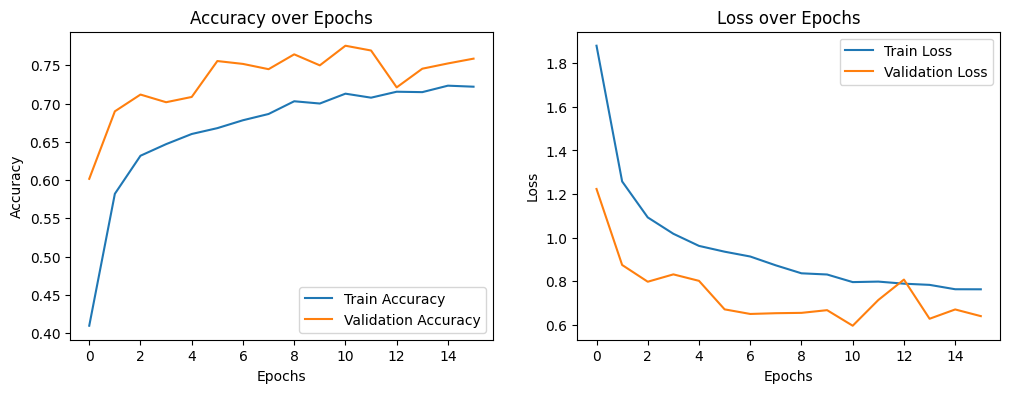

In [17]:
# 10. Eğitim ve Doğrulama Performansını Görselleştir
plt.figure(figsize=(12, 4))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Kayıp Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [18]:
# 11. Modeli Kaydet
model.save("gastro_classification_model.h5")
print("Model başarıyla kaydedildi: gastro_classification_model.h5")

Model başarıyla kaydedildi: gastro_classification_model.h5
